# Imports and Set Up

In [1]:
!pip -q install datasets sentencepiece nltk pyarrow duckdb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, IterableDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

import numpy as np

import sentencepiece as spm
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from datasets import load_dataset

import pyarrow as pa
import pyarrow.parquet as pq
import duckdb
import tempfile

import matplotlib.pyplot as plt

import math, os, re, random, psutil, urllib.request, itertools
from collections import Counter

def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
set_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

cuda


In [2]:
#preprocessing hyperparameters:
stream_corpus = False    #streams corpus to prevent memory explosion when generating random subset; note may take a while if True
corpus_size = 10_000 #num articles
vocab_size = 20_000
character_coverage = 1.0
input_sentence_size = 0 #value of 0 trains tokenizer on full corpus subset

sst2_split_percent = False #val-test split for sst2; cannot use dedicated test set because answers are withheld from the public; value of False uses val set for test set

#higher values increase strength of pruning; paper says values near 1e-5 tend to do well, but higher values are needed here since we use a subword tokenization approach
subsample_threshold = 5e-3

glove_context_len = 10  #context_len needed at preproc time for glove


# Loading Datasets

In [3]:
#load datasets

corpus = load_dataset(
    "wikimedia/wikipedia",
    "20231101.en",
    split="train",
    streaming=stream_corpus
)

if stream_corpus:
    #use reservoir sampling to generate a random subset of the corpus without memory explosion
    reservoir = []
    total_articles = 0
    for i, article in enumerate(corpus):
        total_articles += 1
        if i < corpus_size:
            reservoir.append(article)
        else:
            j = random.randint(0, i)
            if j < corpus_size:
                reservoir[j] = article
        num_selected = len(reservoir) #should be same as corpus_size
else:
    total_articles = len(corpus)
    article_idxs = random.sample(range(len(corpus)), corpus_size)
    corpus = corpus.select(article_idxs)
    num_selected = len(corpus)  #should be same as corpus_size


print(f"total articles in corpus:", total_articles)
print(f"total randomly selected articles:", num_selected)

sst2 = load_dataset("glue", "sst2")
sst2_train, sst2_val_temp = sst2["train"], sst2["validation"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

20231101.en/train-00000-of-00041.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

20231101.en/train-00001-of-00041.parquet:   0%|          | 0.00/351M [00:00<?, ?B/s]

...

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

# Tokenization

In [4]:
#sentencepiece tokenizer setup
sp_dir = "spm"
os.makedirs(sp_dir, exist_ok=True)

corpus_path = os.path.join(sp_dir, "corpus.txt")
with open(corpus_path, "w", encoding="utf-8") as f:
  iterator = reservoir if stream_corpus else corpus
  for article in iterator:
      f.write(article["text"])
      f.write("\n")

spm_prefix = os.path.join(sp_dir, "tokenizer")

In [5]:
#train tokenizer
spm.SentencePieceTrainer.Train(
    input=corpus_path,
    model_prefix=spm_prefix,
    vocab_size=vocab_size,
    model_type="unigram",
    character_coverage=character_coverage,
    input_sentence_size=input_sentence_size,
    shuffle_input_sentence=True,
    pad_id=0, unk_id=1,
    bos_id=-1, eos_id=-1,
    control_symbols='<mask>',
    minloglevel=1 #less verbose training output
)
pad_id, unk_id = 0, 1

In [6]:
#load tokenizer
sp = spm.SentencePieceProcessor()
sp.load(spm_prefix + ".model")
mask_id = sp.piece_to_id("<mask>")
print("mask id:", mask_id)

mask id: 2


In [7]:
#tokenize corpus
preproc_dir = "preprocessing"
os.makedirs(preproc_dir, exist_ok=True)
ids_path = os.path.join(preproc_dir, "ids.bin")  #will store token ids of corpus
left_bounds_path = os.path.join(preproc_dir, "left_bounds.bin")  #will store starting index of sentence for each token in the corpus
right_bounds_path = os.path.join(preproc_dir, "right_bounds.bin")  #will store ending index of sentence for each token in the corpus

i=0
num_sents = 0
chunk_size = 10_000
with open(corpus_path, "r", encoding="utf-8") as f, open(ids_path, "wb") as out_ids, open(left_bounds_path, "wb") as out_left_bounds, open(right_bounds_path, "wb") as out_right_bounds:
    while True:
        lines = list(itertools.islice(f, chunk_size)) #deal with chunk_size lines at a time; faser than just 1 and more memory efficient then all
        if not lines:
            break

        #use sentence tokenizer to find sentence boundaries
        sentences = []
        for line in lines:
            sentences.extend(sent_tokenize(line))
        num_sents += len(sentences)

        token_lists = sp.encode(sentences, out_type=int)  #tokenizations of each sentence
        flat = np.concatenate(token_lists).astype(np.int32)
        flat.tofile(out_ids)

        lengths = [len(t) for t in token_lists]   #lengths of each sentence
        sent_starts = i + np.cumsum( np.concatenate(([0], lengths[:-1])) )
        left_bounds = np.repeat(sent_starts, lengths)
        sent_ends = sent_starts + lengths - 1
        right_bounds = np.repeat(sent_ends, lengths)
        i+=len(flat)

        left_bounds.astype(np.int64).tofile(out_left_bounds)
        right_bounds.astype(np.int64).tofile(out_right_bounds)

ids = np.memmap(ids_path, dtype=np.int32, mode='r')
left_bounds = np.memmap(left_bounds_path, dtype=np.int64, mode='r')
right_bounds = np.memmap(right_bounds_path, dtype=np.int64, mode='r')
ids = torch.from_numpy(ids)
left_bounds = torch.from_numpy(left_bounds)
right_bounds = torch.from_numpy(right_bounds)
print(ids.shape, left_bounds.shape, right_bounds.shape)

print("num tokens in corpus subset:", len(ids))
print("num sentences in corpus subset:", num_sents)

num_unk = (ids == unk_id).sum().item()

print("unk ratio:", num_unk / len(ids))

V = sp.get_piece_size()
print("vocab size:", V)

print(sp.encode("The sky is blue. antidisestablishmentarianism--;", out_type=str))

torch.Size([7066147]) torch.Size([7066147]) torch.Size([7066147])
num tokens in corpus subset: 7066147
num sentences in corpus subset: 395594
unk ratio: 0.0
vocab size: 20000
['▁The', '▁sky', '▁is', '▁blue', '.', '▁anti', 'dis', 'establish', 'ment', 'arian', 'ism', '-', '-', ';']


/tmp/ipykernel_8552/257830682.py:40: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  ids = torch.from_numpy(ids)


In [8]:
#create masked version of corpus, with some tokens masked due to frequency subsampling
masked_ids_path = os.path.join(preproc_dir, "masked_ids.bin")  #will store token ids of masked corpus

#streams ids in chunks in chunks of size chunk_size
def stream_ids(ids, chunk_size=10_000):
    i=0
    while i < len(ids):
        yield ids[i:i+chunk_size]
        i+=chunk_size

#returns unigram probs of the tokens in ids as a tensor of shape [vocab_size,]
def create_unigram_distr(ids):
    unigram = torch.zeros(vocab_size, dtype=torch.long)
    for chunk in stream_ids(ids):   #stream in case ids is large
        counts = torch.bincount(chunk, minlength=V)
        unigram += counts
    unigram = unigram.float() / unigram.sum()
    return unigram

#apply filtering
chunk_size = 10_000
num_keep = 0
unigram = torch.clamp(create_unigram_distr(ids), min=1e-12)
subsample_distr = torch.clamp(1 - torch.sqrt(subsample_threshold / unigram), 0.0, 1.0 )   #formula from paper; gives probs for dropping tokens
with open(masked_ids_path, "wb") as out_masked_ids:
    for ids_chunk in stream_ids(ids, chunk_size):
        probs = subsample_distr[ids_chunk]    #[chunk_size,]
        keep = ~( torch.rand(len(ids_chunk)) < probs )   #boolean mask; prob Uniform(0,1) var is < p is p
        num_keep += keep.sum().item()

        masked_ids_chunk = torch.where(keep, ids_chunk, torch.full_like(ids_chunk, mask_id))
        masked_ids_chunk.numpy().astype(np.int32).tofile(out_masked_ids)

masked_ids = np.memmap(masked_ids_path, dtype=np.int32, mode='r')
masked_ids = torch.from_numpy(masked_ids)
print(masked_ids.shape)
print("num removed tokens:", len(ids) - num_keep)

torch.Size([7066147])
num removed tokens: 871650


In [9]:
#tokenize sentiment analysis dataset

#dataset is small so can store in memory

max_len_val=150
max_len = max_len_val

#returns padded tokenizations of examples from sst2, along with their lengths (from before padding) and labels
def tokenize_and_pad(examples):
    global max_len
    toks = [sp.encode(s, out_type=int)[:max_len] for s in examples["sentence"]]
    lengths = torch.tensor([len(ex) for ex in toks])
    max_len = min( max([len(t) for t in toks]), max_len)
    print("max len:", max_len)
    for i, ex in enumerate(toks):
        toks[i] = torch.tensor(ex + [pad_id] * (max_len - len(ex)), dtype=torch.int32)
    toks = torch.stack(toks)
    labels = torch.tensor(examples["label"], dtype=torch.int32)
    assert toks.shape[0] == labels.shape[0] == lengths.shape[0], "shapes must match"
    max_len = max_len_val
    return toks, lengths, labels

sst2_train_ids, sst2_train_lengths, sst2_train_labels = tokenize_and_pad(sst2_train)

temp = tokenize_and_pad(sst2_val_temp)
if sst2_split_percent:
  sst2_split = int(sst2_split_percent * len(sst2_val_temp))
  sst2_val_ids, sst2_val_lengths, sst2_val_labels = (x[:sst2_split] for x in temp)
  sst2_test_ids, sst2_test_lengths, sst2_test_labels = (x[sst2_split:] for x in temp)
else:
  sst2_val_ids, sst2_val_lengths, sst2_val_labels = temp
  sst2_test_ids, sst2_test_lengths, sst2_test_labels = temp

print(sst2_train_ids.shape, sst2_val_ids.shape, sst2_test_ids.shape)
print("\nnum sentiment analysis examples for each split:")
print("train examples:", len(sst2_train_ids), "val examples:", len(sst2_val_ids), "test examples:", len(sst2_test_ids))

max len: 79
max len: 71
torch.Size([67349, 79]) torch.Size([872, 71]) torch.Size([872, 71])

num sentiment analysis examples for each split:
train examples: 67349 val examples: 872 test examples: 872


# Pre-Processing for GloVe

In [10]:
#GloVe preprocessing helpers

def glove_stats_chunk(ids, left_bounds, right_bounds, start_idx, L):
  #ids: tokenized corpus
  #left_bounds: index of the beginning of the sentence each token is in
  #right_bounds: index of the end of the sentence each token is in
  #finds and returns the glove statistics (center_ids, context_ids, weighted_counts) for a chunk of the corpus of size chunk_size starting at index i

    device = ids.device

    #[start_idx, ..., start_idx+L-1]
    center_idxs = start_idx + torch.arange(L, device=device)   #[L,]

    #[-C, ..., -1, 1, ..., C]
    context_offsets = torch.cat([ torch.arange(-glove_context_len, 0, device=device), torch.arange(1, glove_context_len+1, device=device) ])  #[2C,]

    #[[start_idx-C, ..., start_idx-1, start_idx+1, ..., start_idx+C],
    #...,
    # [start_idx+L-1-C, ..., start_idx+L-1-1, start_idx+L-1+1, ..., start_idx+L-1+C]]
    context_idxs = center_idxs.unsqueeze(1) + context_offsets    #[L,2C]

    left_bounds_chunk = left_bounds[start_idx : start_idx+L]   #[L,]
    right_bounds_chunk = right_bounds[start_idx : start_idx+L] #[L,]
    left_bounds_chunk = left_bounds_chunk.unsqueeze(1)      #[L,1]
    right_bounds_chunk = right_bounds_chunk.unsqueeze(1)    #[L,1]
    valid = (context_idxs >= left_bounds_chunk) & (context_idxs <= right_bounds_chunk)  #boolean mask that is true where context_idxs represents an actual co-occurrence; [L,2C]

    #row and column indices of valid entries of context_idxs
    row_idxs, col_idxs = torch.where(valid)     #[total number of co-occurences,]

    #idxs of the center words for all the found co-occurrences
    center_idxs = start_idx + row_idxs   #[total number of co-occurences,]
    center_ids = ids[start_idx + row_idxs]

    context_idxs = context_idxs[row_idxs, col_idxs] #corpus idxs of the context words for all the found co-occurences; [total number of co-occurences,]
    context_ids = ids[context_idxs]          #ids of context words for all the found co-occurrences

    distances = torch.abs(center_idxs - context_idxs)  #distances for each of the found co-occurences
    weighted_counts = 1.0 / distances.float()   #formula from glove paper

    return center_ids.cpu().numpy().astype(np.int32), context_ids.cpu().numpy().astype(np.int32), weighted_counts.cpu().numpy().astype(np.float32)


#writes chunked glove statistics to parquet path in chunks of size chunk_size; note statistics will still need to be aggregated
def write_stat_chunks(parquet_path, ids, left_bounds, right_bounds, chunk_size=10_000):
    #ids: tokenized corpus
    #left_bounds: index of the beginning of the sentence each token is in
    #right_bounds: index of the end of the sentence each token is in

    schema = pa.schema([
        ("center_id", pa.int32()),
        ("context_id", pa.int32()),
        ("count", pa.float32())
    ])

    with pq.ParquetWriter(parquet_path, schema) as writer:
      for chunk_start in range(0, len(ids), chunk_size):
          chunk_end = min(chunk_start + chunk_size, len(ids))
          center_ids, context_ids, counts = glove_stats_chunk(ids, left_bounds, right_bounds, chunk_start, L=chunk_end-chunk_start)

          if len(center_ids) == 0:
              continue  #should never happen but hypothetically its possible for sentence boundaries to isolate tokens

          #create a pyarrow table and write/append to parquet
          table = pa.table({
              "center_id": center_ids,
              "context_id": context_ids,
              "count": counts
          })
          writer.write_table(table)

#aggregates statistics from parquet_path into final torch.tensor views of numpy memmaps for center_ids, context_ids, and counts, which are stored in their given paths
def aggregate_stats(parquet_path, center_ids_path, context_ids_path, counts_path, chunk_size=10_000):
    #chunk_size: chunk size for iterating over final aggregated statistics
    #returns final statistics: center_ids, context_ids, counts

    with tempfile.TemporaryDirectory(prefix="duckdb_spill_") as temp_dir_path,\
          duckdb.connect() as con,\
          open(center_ids_path, "wb") as out_center_ids,\
          open(context_ids_path, "wb") as out_context_ids,\
          open(counts_path, "wb") as out_counts:

        con.execute(f"SET temp_directory = '{temp_dir_path}'")  #use temp dir for if spill happens during aggregation query
        con.execute(f"CREATE OR REPLACE VIEW glove_stats AS SELECT * FROM '{parquet_path}'")  #register glove_stats into db
        pseudo_rand_seed = 42
        query = f"""
            SELECT center_id, context_id, count
            FROM (
              SELECT center_id, context_id, CAST(SUM(count) AS FLOAT) AS count, ROW_NUMBER() OVER () AS rn
              FROM glove_stats
              GROUP BY center_id, context_id
        )
        ORDER BY hash(rn + {pseudo_rand_seed})
        """   #aggregation query; pseudorandom ordering ensures train and val sets will come from same distribtution
        reader = con.execute(query).fetch_record_batch(chunk_size)

        #still load results in batches because glove stats are O(corpus_size^0.8)
        for batch in reader:
            center_ids_batch = batch.column(0).to_numpy()
            context_ids_batch = batch.column(1).to_numpy()
            counts_batch = batch.column(2).to_numpy()

            center_ids_batch.tofile(out_center_ids)
            context_ids_batch.tofile(out_context_ids)
            counts_batch.tofile(out_counts)

    center_ids = np.memmap(center_ids_path, dtype=np.int32, mode='r')
    context_ids = np.memmap(context_ids_path, dtype=np.int32, mode='r')
    counts = np.memmap(counts_path, dtype=np.float32, mode='r')
    center_ids = torch.from_numpy(center_ids)
    context_ids = torch.from_numpy(context_ids)
    counts = torch.from_numpy(counts)
    return center_ids, context_ids, counts


In [11]:
#GloVe preprocessing
chunk_size = 100_000
parquet_path = os.path.join(preproc_dir, "glove_batched_stats.parquet")
center_ids_path = os.path.join(preproc_dir, "center_ids.bin")
context_ids_path = os.path.join(preproc_dir, "context_ids.bin")
counts_path = os.path.join(preproc_dir, "count_ids.bin")

write_stat_chunks(parquet_path, ids, left_bounds, right_bounds, chunk_size)
center_ids, context_ids, counts = aggregate_stats(parquet_path, center_ids_path, context_ids_path, counts_path, chunk_size)

print(center_ids.shape, context_ids.shape, counts.shape)
print("co-occurrence example:")
print("center token:",sp.IdToPiece(center_ids[0].item()), ", context token:", sp.IdToPiece(context_ids[0].item()), "weighted co-occurrence count:", counts[0].item())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

torch.Size([20506597]) torch.Size([20506597]) torch.Size([20506597])
co-occurrence example:
center token: ▁Che , context token: ▁following weighted co-occurrence count: 0.10000000149011612


# Defining Data Processing Pipelines

In [12]:
#create train, val split
w2v_percent = 0.9
glove_percent = 0.9

split = int(len(ids) * w2v_percent)
split = right_bounds[split]+1 #beginning of sentence

train_ids = ids[:split]
val_ids = ids[split:]
train_left_bounds = left_bounds[:split]
val_left_bounds = left_bounds[split:]
train_right_bounds = right_bounds[:split]
val_right_bounds = right_bounds[split:]

train_masked_ids = masked_ids[:split]
#no need for masked val ids; can just use normal val ids; still need to only include masked ids before split so masked train ids dont see validation data

#offset for corpus indices for left/right bounds for val split
#could just subtract this from val left/right bounds but i do not want to make a new tensor and destroy the memmap structure
val_offset = len(train_ids)

split = int(len(center_ids) * glove_percent)
train_center_ids = center_ids[:split]
val_center_ids = center_ids[split:]
train_context_ids = context_ids[:split]
val_context_ids = context_ids[split:]
train_counts = counts[:split]
val_counts = counts[split:]

print("number of tokens in train corpus:", len(train_ids))
print("number of tokens in val corpus:", len(val_ids))
print("number of tokens in masked train corpus:", len(train_masked_ids))
print("number of glove train examples:", len(train_center_ids))
print("number of glove val examples:", len(val_center_ids))
print("shape test:", train_ids.shape == train_left_bounds.shape == train_right_bounds.shape == train_masked_ids.shape,\
      val_ids.shape == val_left_bounds.shape == val_right_bounds.shape,\
      train_center_ids.shape == train_context_ids.shape == train_counts.shape,\
      val_center_ids.shape == val_context_ids.shape == val_counts.shape)
print(len(train_ids) / len(val_ids), len(train_center_ids) / len(val_center_ids))

number of tokens in train corpus: 6359555
number of tokens in val corpus: 706592
number of tokens in masked train corpus: 6359555
number of glove train examples: 18455937
number of glove val examples: 2050660
shape test: True True True True
9.000321260359586 8.999998537056362


In [13]:
#batch loaders

#use iterable dataset to keep useful internal variables
#note number of examples per iteration over dataset may change due to random window length (this is why a normal Dataset object is not used)

#skipgram batch loader
#note this class is used for both pure sg and for sgns; sgns loading uses a collate_fn to tack on negative samples
class SGCorpusDataset(IterableDataset):
  def __init__(self, ids, context_len, left_bounds=None, right_bounds=None, offset=0):
    assert (left_bounds is not None and right_bounds is not None) or (left_bounds is None and right_bounds is None), "must provide both left and right bounds or neither"
    self.is_bounds = left_bounds is not None
    if self.is_bounds:
      assert ids.shape == left_bounds.shape == right_bounds.shape, "shapes must match"
    self.ids = ids
    self.context_len = context_len
    self.left_bounds = left_bounds
    self.right_bounds = right_bounds
    self.offset = offset    #offset to apply to corpus indices (for val set due to split that starts at nonzero index)
    self.epoch = 1  #used to share rng seeds across workers

  #changes random seed
  def increment_epoch(self):
    self.epoch += 1

  #yields each training example
  def __iter__(self):
      #model input: center tok id. target: context tok id
      #shuffle dataset
      g = torch.Generator()
      g.manual_seed(self.epoch)  #different shuffling each epoch

      worker_info = torch.utils.data.get_worker_info()
      if worker_info is None:
          indices = torch.randperm(len(self.ids), generator=g)
      else:
          indices = torch.randperm(len(self.ids), generator=g)
          indices = indices[worker_info.id::worker_info.num_workers]  #forces no replacement for samples

      for center_idx in indices:
          center_idx = center_idx.item()
          center_id = self.ids[center_idx]
          if center_id.item() == mask_id: continue  #skip masked tokens
          win_len = random.randint(1, self.context_len)   #reduce prob of distant words as per original w2v implementation
          if self.is_bounds:
            sent_start = self.left_bounds[center_idx] - self.offset
            sent_end = self.right_bounds[center_idx] - self.offset
          else:
            sent_start = 0
            sent_end = len(self.ids)-1

          left_bound = max(sent_start, center_idx - win_len)
          right_bound = min(sent_end, center_idx + win_len)

          for context_idx in range(left_bound, right_bound+1):
              if context_idx == center_idx: continue    #avoid context word = center word
              context_id = self.ids[context_idx]
              if context_id.item() == mask_id: continue  #skip masked tokens
              yield center_id.long(), context_id.long()


#contiguous bag of words batch loader
class CBOWCorpusDataset(IterableDataset):
  def __init__(self, ids, context_len, left_bounds=None, right_bounds=None, offset=0):
    assert (left_bounds is not None and right_bounds is not None) or (left_bounds is None and right_bounds is None), "must provide both left and right bounds or neither"
    self.is_bounds = left_bounds is not None
    if self.is_bounds:
      assert ids.shape == left_bounds.shape == right_bounds.shape, "shapes must match"
    self.ids = ids
    self.context_len = context_len
    self.left_bounds = left_bounds
    self.right_bounds = right_bounds
    self.offset = offset
    self.t = 2 * context_len   #total entries in context after padding
    self.epoch = 1

  #changes random seed
  def increment_epoch(self):
      self.epoch += 1

  #yields each training example
  def __iter__(self):
      #model input: context tok ids. target: center tok id
      #shuffle dataset
      g = torch.Generator()
      g.manual_seed(self.epoch)
      worker_info = torch.utils.data.get_worker_info()
      if worker_info is None:
          indices = torch.randperm(len(self.ids), generator=g)
      else:
          indices = torch.randperm(len(self.ids), generator=g)
          indices = indices[worker_info.id::worker_info.num_workers]

      for center_idx in indices:
          center_idx = center_idx.item()
          win_len = random.randint(1, self.context_len)   #reduce prob of distant words
          if self.is_bounds:
            sent_start = self.left_bounds[center_idx] - self.offset
            sent_end = self.right_bounds[center_idx] - self.offset
          else:
            sent_start = 0
            sent_end = len(self.ids)-1

          left_bound = max(sent_start, center_idx - win_len)
          right_bound = min(sent_end, center_idx + win_len)
          ctx_idxs = [i for i in range(left_bound, right_bound+1) if i!=center_idx]   #avoid context word = center word

          l = len(ctx_idxs)
          if l == 0: continue   #skip single word sentences
          pad_len = self.t - l
          context = torch.cat( [self.ids[ctx_idxs], torch.full((pad_len,), pad_id, dtype=self.ids.dtype)])
          yield context.long(), self.ids[center_idx].long(), l    #pass l so cbow knows what to use as size of context when computing mean

#glove batch loader
class GloVeDataset(Dataset):
    def __init__(self, center_ids, context_ids, counts):
        self.center_ids = center_ids
        self.context_ids = context_ids
        self.counts = counts
        assert len(center_ids) == len(context_ids) == len(counts), "must have same length"

    def __len__(self):
        return len(self.center_ids)

    def __getitem__(self, idx):
        return self.center_ids[idx], self.context_ids[idx], self.counts[idx]

#sst2 batch loader
class SST2Dataset(Dataset):
    def __init__(self, ids, lengths, labels):
        self.ids = ids    #[dataset_size, max_len]
        self.labels = labels  #[dataset_size,]
        self.lengths = lengths  #[dataset_size,]
        assert len(ids) == len(labels) == len(lengths), "must have same length"

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        return self.ids[idx], self.lengths[idx], self.labels[idx]

## Batch Loading Helpers

In [14]:
#helpers for sgns batch loading

#creates an augmented distribution from the unigram distribution of ids of shape [vocab_size,] to be used for negative sampling
def create_neg_distr(ids, exponent=0.75):
  #exponent: should be from [0,1]; lower values boost the representation of rare words
  unigram = create_unigram_distr(ids)
  distr = unigram ** exponent
  distr = distr / distr.sum()
  return distr

#creates negative samples for a batch all at once
class NegativeSampler():
  def __init__(self, batch_size, num_neg, exponent=None, neg_distr=None):
    #neg_dist: pytorch tensor of probs; the ith prob is the prob that token i is sampled; must be a prob distr
    if neg_distr is None:
      neg_distr = create_neg_distr(ids, exponent)
    assert torch.all(neg_distr >= 0), "prob distr must have nonnegative probs"
    assert torch.isclose(neg_distr.sum(), torch.tensor(1.0), atol=1e-6), "prob distr must sum to 1"
    self.neg_distr = neg_distr
    self.batch_size = batch_size
    self.num_neg = num_neg
    self.num_samples = self.batch_size * self.num_neg

  def sample(self):
    sample_ids = torch.multinomial(self.neg_distr, num_samples=self.num_samples, replacement=True).view(self.batch_size, self.num_neg)  #[batch_size, num_neg]
    return sample_ids

  #collates a batch of positive sgns samples with negative samples
  #returns collated batch: center ids, context ids, negative sample ids
  def sgns_collate_fn(self, batch):
      neg_samples = self.sample()
      centers, contexts = zip(*batch)
      centers = torch.stack(centers)
      contexts = torch.stack(contexts)
      return centers, contexts, neg_samples

In [15]:
#helper for lstm batch loading
#returns batch sorted by decreasing lengths: token ids, example lengths, sentiment labels
def collate_sort(batch):
    ids, lengths, labels = zip(*batch)
    ids, lengths, labels = torch.stack(ids), torch.stack(lengths), torch.stack(labels)
    lengths, idxs = lengths.sort(descending=True)
    ids = ids[idxs]
    labels = labels[idxs]
    return ids, lengths, labels


# Defining Models

In [16]:
#models

divide_logits = lambda d : math.sqrt(d)#1   #sqrt(d) gives better pretraining loss but 1 sometimes gives better final eval accuracy

#pure skipgram model
class Skipgram(nn.Module):
    def __init__(self, d_model, vocab_size):
      #d_model: embedding dimension
      #vocab_size: vocab size
      super().__init__()
      self.d_model = d_model
      self.vocab_size = vocab_size
      self.emb_center = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.emb_context = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.divide_logits = divide_logits (d_model)

    #predict context given center
    def forward(self, center, context=None):
      #inputs: [B,] token ids
      #returns logits; returns loss as well if label given
      emb_center = self.emb_center(center)  #[B,d_model]
      emb_context = self.emb_context.weight #[V,d_model]
      logits = emb_center @ emb_context.transpose(0,1) / self.divide_logits  #[B,V]
      if context is None:
        return logits
      loss = F.cross_entropy(logits, context)
      return logits, loss

    #returns logits of distribution formed from inner products with given embeddings
    def infer(self, center):
      #center: [B,]
      logits = self.forward(center)
      return logits.argmax(dim=1)

#pure contiguous bag of words model
class CBOW(nn.Module):
    def __init__(self, d_model, vocab_size):
      #d_model: embedding dimension
      #vocab_size: vocab size
      super().__init__()
      self.d_model = d_model
      self.vocab_size = vocab_size
      self.emb_center = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.emb_context = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.divide_logits = divide_logits (d_model)

    #predict center given context
    #take average of context embeddings to get single context representation as per CBOW formula
    def forward(self, context, center=None, lengths=None):
      #context: [B, 2C] token ids
      #center: [B,] token ids
      #lengths: [B,] non padded context lengths
      #returns logits; returns loss as well if label given
      emb_context = self.emb_context(context).sum(dim=1) / lengths.unsqueeze(1) #[B,d_model]; note embedding of pad token is 0 and so does not affect sum()
      emb_center = self.emb_center.weight #[V,d_model]
      logits = emb_context @ emb_center.transpose(0,1) / self.divide_logits #[B,V]
      if center is None:
        return logits
      loss = F.cross_entropy(logits, center)
      return logits, loss

    #returns logits of distribution formed from inner products with given embeddings
    def infer(self, context):
      #context: [B, 2C]
      logits = self.forward(context)
      return logits.argmax(dim=1)

#skipgram with negative sampling model
class SGNS(nn.Module):
    def __init__(self, d_model, vocab_size):
      #d_model: embedding dimension
      #vocab_size: vocab size
      super().__init__()
      self.d_model = d_model
      self.vocab_size = vocab_size
      self.emb_center = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.emb_context = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.divide_logits = divide_logits (d_model)

    #predict probabilities that given pairs co-occur
    def forward(self, center, context, neg_samples=None):
      #center, context: each [B,] token ids
      #neg_samples: [B, num_neg] token ids
      #returns logits; returns loss as well if label given
      emb_center = self.emb_center(center)  #[B,d_model]
      emb_context = self.emb_context(context) #[B,d_model]
      pos_logits = (emb_center * emb_context).sum(dim=1) / self.divide_logits #[B,]
      if neg_samples is None:
        return pos_logits
      emb_neg = self.emb_context(neg_samples) #[B,num_neg,d_model]
      neg_logits = (emb_center.unsqueeze(1) * emb_neg).sum(dim=2) / self.divide_logits  #[B,num_neg]
      loss = -( F.logsigmoid(pos_logits) + F.logsigmoid(-neg_logits).sum(dim=1) ).mean()
      return pos_logits, loss

    #returns logits of distribution formed from inner products with given embeddings
    def infer(self, center):
      #center: [B,]
      embs = self.emb_center(center)
      logits = embs @ self.emb_context.weight.traspose(0,1) / self.divide_logits
      return logits.argmax(dim=1)

#glove model
class GloVe(nn.Module):
    def __init__(self, d_model, vocab_size, x_max, alpha):
      #d_model: embedding dimension
      #vocab_size: vocab size
      #x_max: threshold count at which weighting function saturates to 1
      #alpha: shape parameter for weighinting function
      super().__init__()
      self.d_model = d_model
      self.vocab_size = vocab_size
      self.x_max = x_max
      self.alpha = alpha
      self.emb_center = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.emb_context = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
      self.bias_center = nn.Embedding(vocab_size, 1, padding_idx=pad_id)
      self.bias_context = nn.Embedding(vocab_size, 1, padding_idx=pad_id)
      #zero intilization for biases
      self.bias_center.weight.data.zero_()
      self.bias_context.weight.data.zero_()

      self.divide_logits = divide_logits (d_model)

    #helper weighting function for GloVe loss
    def f_weight(self, x):
        #x: [B,] counts
        #returns [B,] weights
        weight = torch.clamp( (x / self.x_max) ** self.alpha, max=1.0)  #[B,]
        return weight

    #predict log co-occurrence counts for given pairs
    def forward(self, center, context, count):
      #center, context, count: each [B,] glove statistics
      #returns logits and loss
      emb_center = self.emb_center(center)    #[B, d_model]
      emb_context = self.emb_context(context) #[B, d_model]
      bias_center = self.bias_center(center)  #[B, 1]
      bias_context = self.bias_context(context) #[B,1]
      preds = (emb_center * emb_context).sum(dim=1) / self.divide_logits + bias_center.squeeze(1) + bias_context.squeeze(1)  #[B,]

      logcount = torch.log(count)  #[B,]
      weight = self.f_weight(count)
      squared_errs = F.mse_loss(preds, logcount, reduction='none')   #[B,]
      loss = (weight * squared_errs).mean()
      return preds, loss

    #returns logits of distribution formed from inner products with given embeddings
    def infer(self, center):
      #tok_ids: [B,]
      embs = self.emb_center(center)
      logits = embs @ self.emb_context.weight.transpose(0,1) / self.divide_logits
      return logits.argmax(dim=1)

#unidirectional lstm classification head
class lstm_head(nn.Module):
    def __init__(self, d_model, h_model, num_classes, dropout, num_layers, use_ln, use_affine):
      #d_model: embedding dimension
      #h_model: lstm hidden dimension
      #num_classes: num sentiment classes
      #dropout: dropout for lstm
      #num_layers: depth of lstm
      #use_ln: controls if layer norm is used
      #use_affine: controls if layer norm uses affine transformation or not
      super().__init__()
      self.d_model = d_model    #dim of underlying embeddings
      self.h_model = h_model    #dim for lstm hidden states
      self.num_classes = num_classes
      self.num_layers = num_layers
      self.use_ln = use_ln  #controls whether layer norm is used before embeddings are fed to lstm
      if use_ln:
        self.ln = nn.LayerNorm(d_model, elementwise_affine=use_affine)
      self.lstm = nn.LSTM(d_model, h_model, batch_first=True, bidirectional=False, dropout=dropout, num_layers=num_layers)
      self.dropout = nn.Dropout(dropout)
      self.fc = nn.Linear(h_model, num_classes)

    #predict sentiment classes from given embedding sequences
    def forward(self, embs, lengths):
      #embs: [B,L,d_model]
      #lengths: [B,] for sequence packing, or None
      #returns logits for sentiment classes
      if self.use_ln:
        embs = self.ln(embs)
      #pack sequences to ensure pad tokens are not processed by lstm
      if lengths is not None: embs = pack_padded_sequence(embs, lengths, batch_first=True, enforce_sorted=True) #embs and lenths should be presorted
      _, (h, _) = self.lstm(embs)  #[num_layers*num_directions, B, h_model]
      h_f = h[-1] #[B, h_model]
      h_f = self.dropout(h_f)
      logits = self.fc(h_f) #[B, num_classes]
      return logits

#uses given embs to perform sentiment analysis with lstm
class Sentiment_Analaysis(nn.Module):
  def __init__(self, embs, h_model, num_classes, dropout, num_layers, freeze_embs=True, use_ln=True, use_affine=True):
    #embs: [V,d_model] embedding table to use to embed tok ids
    #h_model: lstm hidden dimension
    #num_classes: num sentiment classes
    #dropout: dropout for embeddings and lstm
    #num_layers: depth of lstm
    #freeze_embs: controls if given embeddings are frozen or fine tuned
    #use_ln: controls if layer norm is used
    #use_affine: controls if layer norm uses affine transformation or not
    super().__init__()
    assert num_classes > 1, "must have at least 2 classes"
    if num_classes == 2:
        out_features = 1  #one logit per example for binary cross entropy
    else:
        out_features = num_classes
    self.num_classes = num_classes
    self.freeze_embs = freeze_embs
    d_model = embs.shape[1]
    self.embs = nn.Embedding.from_pretrained(embs, freeze=freeze_embs, padding_idx=pad_id)
    if not freeze_embs: self.dropout = nn.Dropout(dropout)  #embedding dropout for nonfrozen embeddinggs
    self.lstm_head = lstm_head(d_model, h_model, out_features, dropout, num_layers, use_ln=use_ln, use_affine=use_affine)

  #predict sentiment classes for given sequences of token ids
  def forward(self, ids,  lengths=None,labels=None):
    #ids: [B,L] token ids
    #labels: [B,]
    #lengths: [B,] (for sequence packing in lstm), or None
    #returns logits; returns loss as well if label given
    #note ids, labels, and lengths should be sorted by decreasing order according to lengths for packing to work
    e = self.embs(ids)  #[B,L,d_model]
    if not self.freeze_embs: e = self.dropout(e)
    logits = self.lstm_head(e, lengths)  #[B, out_features] (potentially [B,1])
    if labels is None:
      return logits
    if self.num_classes == 2: #binary cross entropy
      loss = F.binary_cross_entropy_with_logits(logits.squeeze(), labels.float())
    else:
      loss = F.cross_entropy(logits, labels)
    return logits, loss


# Training and Evaluation Loops

In [17]:
#training and eval loops

#evluation of loss on dataset
@torch.no_grad()
def eval(model, corpus_loader, num_batches=100, return_accs=False, pack=False):
  #model: model to evaluate
  #corpus_loader: data loader for model
  #num_batches: number of batches to run for evaluation
  #return_accs: returns accuracies if true
  #pack: puts packed sequence lengths to cpu if true
  #returns losses [, accuracies]

  #use num_batches=0 to evaluate on full dataset
  #return_accs should only be used for sentiment analysis
  #pack: put lengths to cpu rather than gpu for lstm model
  model.eval()
  total_loss = 0.0
  num_correct, total = 0, 0
  total_batches = 0   #will be used to calculate the actual number of batches processed (ie if num_batches is higher than the actual number of batches in the loader)
  for i, batch in enumerate(corpus_loader, start=1):
    if num_batches > 0 and i > num_batches: break
    total_batches += 1
    if pack:
        batch = [batch[0].to(device, non_blocking=True), batch[1].cpu(), batch[2].to(device, non_blocking=True)]
    else:
        batch = [tens.to(device, non_blocking=True) for tens in batch]
    logits, loss = model(*batch)
    total_loss += loss.item()
    if return_accs:
      if model.num_classes == 2:
        preds = (logits.squeeze() > 0).int()   #binary class logits
      else:
        preds = logits.argmax(dim=1)    #multiclass logits
      num_correct += (preds == batch[-1]).sum().item()
      total += len(batch[-1])
  avg_loss = total_loss / total_batches
  if return_accs:
    return avg_loss, num_correct / total
  return avg_loss

def train(model, total_steps, train_loader, val_loader, eval_every, optim, scheduler, clip_norm=None, num_val_batches=100, increment_epoch=True, return_accs=False, pack=False):
  #model: model to train
  #total_steps: total steps to train for
  #train_loader: data loader for training model
  #val_loader: data loader for validation
  #eval_every: controls when val evaluation is computed
  #optim: optimizer for model parameters
  #scheduler: lr scheduler for optimizer
  #clip_norm: value to clip gradient norms to, or None if no clipping
  #num_val_batches: number of batches to use when evaluating on val set
  #increment_epoch: increments epoch values for data loaders; only supported by sg and cbow data loaders; ensures random seed is different each epoch
  #return accs: returns accuracies if True; should only be used for sentiment analysis model
  #pack: puts packed sequence lengths to cpu
  #returns train losses, val losses [, val accuracies], num completed epochs
  train_losses = []   #averages over batches
  val_losses = []      #averages over num_val_batches many batches (or over full dataset if num_val_batches set to 0)
  val_accs = []
  num_completed_epochs=0
  step = 0
  while True:
      for batch in train_loader:
          step += 1
          if step > total_steps: break
          model.train()
          if pack:
            batch = [batch[0].to(device, non_blocking=True), batch[1].cpu(), batch[2].to(device, non_blocking=True)]
          else:
            batch = [tens.to(device, non_blocking=True) for tens in batch]
          optim.zero_grad(set_to_none=True)
          logits, loss = model(*batch)
          loss.backward()
          if clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
          optim.step()
          scheduler.step()

          train_losses.append( (step, loss.item()) )
          if step % eval_every == 0:
              if return_accs:
                val_loss, val_acc = eval(model, val_loader, num_val_batches, return_accs=True, pack=pack)
                val_accs.append( (step, val_acc) )
              else:
                val_loss = eval(model, val_loader, num_val_batches)
              val_losses.append( (step, val_loss) )
              if increment_epoch: val_loader.dataset.increment_epoch()  #ensures different shuffle of val set (ie if not using num_val_batches=0)
              if return_accs:
                print(f"step: {step} train loss (noisy): {loss.item()}, val loss: {val_loss}, val acc: {val_acc}")
              else:
                print(f"step: {step} train loss (noisy): {loss.item()}, val loss: {val_loss}")
      if step > total_steps:
        break
      num_completed_epochs += 1
      if increment_epoch: train_loader.dataset.increment_epoch()
  if return_accs:
    return train_losses, val_losses, val_accs, num_completed_epochs
  return train_losses, val_losses, num_completed_epochs

In [18]:
#function for plotting results
def plot_results(train_losses, val_losses, num_completed_epochs=None, chunk_size=1, val_accs=None):
  #train_losses: list of (step, train loss) (x,y) pairs for plotting
  #val_losses: list of (step, val loss) (x,y) pairs for plotting
  #num_completed_epochs: number of epochs completed during training
  #chunk_size: applies smoothing by mean to train_losses on bins of size chunk_size
  #val_accs: list of (step, val acc) (x,y) pairs for plotting
  smooth_train_losses = []
  avg_loss = 0.0
  start_step = 1
  for l in train_losses:
    avg_loss += l[1]
    if l[0] % chunk_size == 0:
      avg_loss /= chunk_size
      end_step = l[0]
      midpoint = int( (start_step + end_step) / 2 )
      smooth_train_losses.append( (midpoint, avg_loss) )
      avg_loss = 0.0
      start_step = l[0]
  plt.plot(*zip(*smooth_train_losses), label="train loss")
  plt.plot(*zip(*val_losses), label="val loss")
  plt.xlabel("Step")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

  if val_accs is not None:
    plt.title("Validation Accuracy")
    plt.plot(*zip(*val_accs), label="val acc")
    plt.show()
  print("total full passes over corpus:", num_completed_epochs)

# Training

## Pure SkipGram Training / Plotting

In [19]:
#pure skipgram training. small model for now. need to upscale model size and do hyperparameter tuning for that

#would be ideal to have all text models of similar size to make sentiment analysis evaluation consistent

total_steps = 1500
warmup_steps = 10
batch_size = 256
num_workers = 2
context_len = 5
d_model = 256
lr=1e-2
weight_decay = 0.01
start_factor = 1e-5
clip_norm = 1.0

eval_every = 20
num_val_batches = 90  #formula: eval_every : num_val_batches / 9 gives train to val compute ratio (formula comes from 90-10 split)


set_seed(0)
sg_train_corpus = SGCorpusDataset(train_ids, context_len, train_left_bounds, train_right_bounds)
sg_val_corpus = SGCorpusDataset(val_ids, context_len, val_left_bounds, val_right_bounds, val_offset)
sg_train_corpus_loader = DataLoader(sg_train_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers, drop_last=True)
sg_val_corpus_loader = DataLoader(sg_val_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers)

sg_model = Skipgram(d_model, V).to(device)

optim = torch.optim.AdamW(sg_model.parameters(), lr=lr, weight_decay=weight_decay)

warmup = torch.optim.lr_scheduler.LinearLR(
    optim,
    start_factor=start_factor,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim,
    T_max=total_steps - warmup_steps
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optim,
    schedulers=[warmup, cosine],
    milestones=[warmup_steps]
)

final_train_args = (sg_model, total_steps, sg_train_corpus_loader, sg_val_corpus_loader, eval_every, optim, scheduler, clip_norm, num_val_batches)
sg_train_losses, sg_val_losses, sg_num_completed_epochs = train(*final_train_args)

step: 20 train loss (noisy): 10.338174819946289, val loss: 10.306810930040147
step: 40 train loss (noisy): 10.19234561920166, val loss: 10.168821260664199
step: 60 train loss (noisy): 10.019533157348633, val loss: 10.050574334462484
step: 80 train loss (noisy): 9.826303482055664, val loss: 9.920469686720107
step: 100 train loss (noisy): 9.786158561706543, val loss: 9.832217926449246
step: 120 train loss (noisy): 9.794607162475586, val loss: 9.743373330434164
step: 140 train loss (noisy): 9.810041427612305, val loss: 9.6288328382704
step: 160 train loss (noisy): 9.42080307006836, val loss: 9.560590140024821
step: 180 train loss (noisy): 9.225957870483398, val loss: 9.446153842078315
step: 200 train loss (noisy): 9.54029655456543, val loss: 9.356397088368734
step: 220 train loss (noisy): 9.337791442871094, val loss: 9.327474880218507
step: 240 train loss (noisy): 9.118634223937988, val loss: 9.277562681833903
step: 260 train loss (noisy): 9.492450714111328, val loss: 9.185682423909505
st

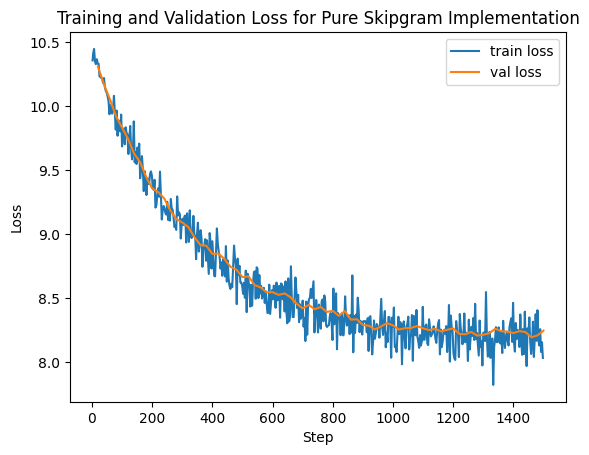

total full passes over corpus: 0


In [20]:
#pure skipgram plotting
chunk_size = 3   #num batches that training loss is averaged over (to smooth curve)

plt.title("Training and Validation Loss for Pure Skipgram Implementation")
plot_results(sg_train_losses, sg_val_losses, sg_num_completed_epochs, chunk_size)

## Pure CBOW Training / Plotting

In [21]:
#pure cbow training
#note a cbow step uses a full context and a center word, whereas skipgram just uses one context word and one center word, so each example and hence batch is more costly here

total_steps = 1500
warmup_steps = 10
batch_size = 256
num_workers = 2
context_len = 5
d_model = 256
lr=1e-2
weight_decay = 0.01
start_factor = 1e-5
clip_norm = 1.0

eval_every = 20
num_val_batches = 90  #formula: eval_every : num_val_batches / 9 gives train to val compute ratio (formula comes from 90-10 split)


set_seed(0)
cbow_train_corpus = CBOWCorpusDataset(train_ids, context_len, train_left_bounds, train_right_bounds)
cbow_val_corpus = CBOWCorpusDataset(val_ids, context_len, val_left_bounds, val_right_bounds, val_offset)
cbow_train_corpus_loader = DataLoader(cbow_train_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers, drop_last=True)
cbow_val_corpus_loader = DataLoader(cbow_val_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers)

cbow_model = CBOW(d_model, V).to(device)

optim = torch.optim.AdamW(cbow_model.parameters(), lr=lr, weight_decay=weight_decay)

warmup = torch.optim.lr_scheduler.LinearLR(
    optim,
    start_factor=start_factor,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim,
    T_max=total_steps - warmup_steps
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optim,
    schedulers=[warmup, cosine],
    milestones=[warmup_steps]
)

final_train_args = (cbow_model, total_steps, cbow_train_corpus_loader, cbow_val_corpus_loader, eval_every, optim, scheduler, clip_norm, num_val_batches)
cbow_train_losses, cbow_val_losses, cbow_num_completed_epochs = train(*final_train_args)

step: 20 train loss (noisy): 9.9095458984375, val loss: 9.923932626512315
step: 40 train loss (noisy): 9.695510864257812, val loss: 9.715956687927246
step: 60 train loss (noisy): 9.401012420654297, val loss: 9.42532377243042
step: 80 train loss (noisy): 9.179301261901855, val loss: 9.064010853237576
step: 100 train loss (noisy): 8.73616886138916, val loss: 8.791230244106716
step: 120 train loss (noisy): 8.502662658691406, val loss: 8.591617478264702
step: 140 train loss (noisy): 8.332250595092773, val loss: 8.489606560601128
step: 160 train loss (noisy): 8.308877944946289, val loss: 8.37988485760159
step: 180 train loss (noisy): 8.109910011291504, val loss: 8.257954666349622
step: 200 train loss (noisy): 7.987632751464844, val loss: 8.169457244873048
step: 220 train loss (noisy): 8.196720123291016, val loss: 8.132889747619629
step: 240 train loss (noisy): 7.99818229675293, val loss: 8.045347298516168
step: 260 train loss (noisy): 7.966960430145264, val loss: 8.01014821794298
step: 280 

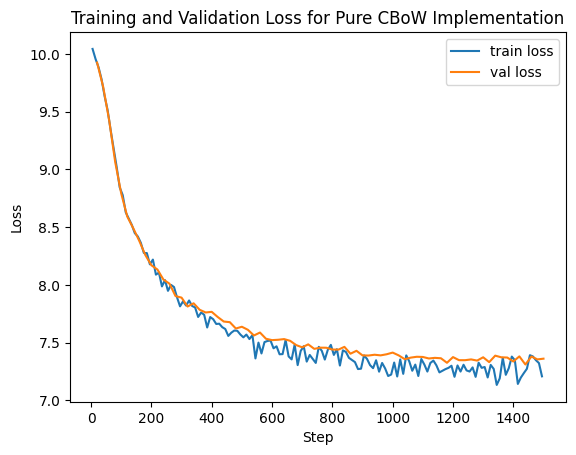

total full passes over corpus: 0


In [22]:
#pure cbow plotting
chunk_size = 10   #num batches that training loss is averaged over (to smooth curve)

plt.title("Training and Validation Loss for Pure CBoW Implementation")
plot_results(cbow_train_losses, cbow_val_losses, cbow_num_completed_epochs, chunk_size)

## SGNS Training / Plotting

In [23]:
#sgns training
#should be able to train way faster since doesnt need to compute logits over entire vocab
#note loss is on different scale then cross entropy loss (which previous models used)

#model gets stuck at val loss of 2.6 when training on large corpus; maybe can try adding floor to cosine anneal so that lr does not become too small
#im training this for an epoch bc i want to see if it works; other models may not be able to train for an epoch due to being slow

#val loss so far is consistently lower than train loss; this is not a problem it is probably because the val loader does not used frequency subsampling,
#which makes the token prediction easier since it has more "easy" exapmles (more common tokens that were otherwise masked out)

total_steps = 250_000   #i estimate 250k should be over 1 epoch for 8 mil toks in corpus, batch size of 256, and context_len of 5
warmup_steps = 50
batch_size = 256
num_workers = 2
context_len = 5
d_model = 512
lr=3e-4
weight_decay = 0
start_factor = 1e-5
clip_norm = 1.0

#new sgns hyperparams:
num_neg = 10   #number of negative samples per positive sample; 2-5 may work for large dataset, up to 20 for small dataset (according to paper)
exponent = 0.75   #lower values give more representation to rare tokens; comes from [0,1] original paper uses 0.75, probably should keep close to this
#note the preprocessing hyperparam subsample_threshold affects only sgns

eval_every = 5_000
num_val_batches = 90  #formula: eval_every : num_val_batches / 9 gives train to val compute ratio (formula comes from 90-10 split)


set_seed(0)
neg_sampler = NegativeSampler(batch_size, num_neg, exponent)
sgns_train_corpus = SGCorpusDataset(train_masked_ids, context_len, train_left_bounds, train_right_bounds)  #use subsampled ids for sgns (only for training)
sgns_val_corpus = SGCorpusDataset(val_ids, context_len, val_left_bounds, val_right_bounds, val_offset)
sgns_train_corpus_loader = DataLoader(sgns_train_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers, drop_last=True, collate_fn=neg_sampler.sgns_collate_fn)
sgns_val_corpus_loader = DataLoader(sgns_val_corpus, batch_size=batch_size, pin_memory=True, num_workers=num_workers, collate_fn=neg_sampler.sgns_collate_fn)

sgns_model = SGNS(d_model, V).to(device)

optim = torch.optim.AdamW(sgns_model.parameters(), lr=lr, weight_decay=weight_decay)

warmup = torch.optim.lr_scheduler.LinearLR(
    optim,
    start_factor=start_factor,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim,
    T_max=total_steps - warmup_steps
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optim,
    schedulers=[warmup, cosine],
    milestones=[warmup_steps]
)

final_train_args = (sgns_model, total_steps, sgns_train_corpus_loader, sgns_val_corpus_loader, eval_every, optim, scheduler, clip_norm, num_val_batches)
sgns_train_losses, sgns_val_losses, sgns_num_completed_epochs = train(*final_train_args)

step: 5000 train loss (noisy): 8.018131256103516, val loss: 8.174499331580268
step: 10000 train loss (noisy): 7.316187858581543, val loss: 7.076597049501207
step: 15000 train loss (noisy): 5.809538841247559, val loss: 6.022562683953179
step: 20000 train loss (noisy): 5.638801574707031, val loss: 5.193421088324653
step: 25000 train loss (noisy): 4.783501148223877, val loss: 4.662954982121786
step: 30000 train loss (noisy): 4.39021110534668, val loss: 4.304395514064365
step: 35000 train loss (noisy): 4.108977794647217, val loss: 4.064365153842502
step: 40000 train loss (noisy): 3.9534189701080322, val loss: 3.8611543628904554
step: 45000 train loss (noisy): 3.682466506958008, val loss: 3.7081349505318535
step: 50000 train loss (noisy): 3.551058292388916, val loss: 3.609112705124749
step: 55000 train loss (noisy): 3.525059700012207, val loss: 3.5639028628667195
step: 60000 train loss (noisy): 3.457801103591919, val loss: 3.4982844988505044
step: 65000 train loss (noisy): 3.287254810333252

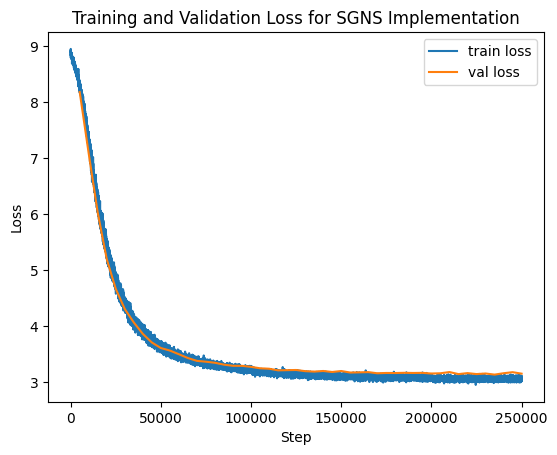

total full passes over corpus: 2


In [24]:
#sgns plotting
chunk_size = 10   #num batches that training loss is averaged over (to smooth curve)

plt.title("Training and Validation Loss for SGNS Implementation")
plot_results(sgns_train_losses, sgns_val_losses, sgns_num_completed_epochs, chunk_size)

## GloVe Training / Plotting

In [25]:
#GloVe training
#should also train faster than pure sg and cbow
#again note loss is not on the same scale as previous losses
#also changing x_max and alpha change the weights of the weighted least-squares loss, so lower losses due to changing those values may not actually be better
#may need to wait until eval is developed to really know what is best here

total_steps = 15_000
warmup_steps = 20
batch_size = 512
num_workers = 2
d_model = 512
lr=5e-3
weight_decay = 1e-2
start_factor = 1e-5
clip_norm = 1.0

#new glove hyperparams
#note context_len is defined during preprocessing for glove
x_max = 100   #the threshold at which the weighting function should saturate to 1
              #lower values give more representation to very rare co-occurrences but will cause "moderately" rare co-occurrences to receive less weighting
alpha = 0.75  #should be > 0 (and not probably not much larger than 1.5, if larger than 1 at all)
              #parameter similar to "exponent" from sgns. controls shape of weighing function; lower values give increases representation to rare words

eval_every = 800
num_val_batches = 270  #formula: eval_every : num_val_batches / 9 gives train to val compute ratio (formula comes from 90-10 split)


set_seed(0)
glove_train_dataset = GloVeDataset(train_center_ids, train_context_ids, train_counts)
glove_val_dataset = GloVeDataset(val_center_ids, val_context_ids, val_counts)
glove_train_loader = DataLoader(glove_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers, drop_last=True)
glove_val_loader = DataLoader(glove_val_dataset, batch_size=batch_size, pin_memory=True, num_workers=num_workers)

glove_model = GloVe(d_model, V, x_max, alpha).to(device)

optim = torch.optim.AdamW(glove_model.parameters(), lr=lr, weight_decay=weight_decay)

warmup = torch.optim.lr_scheduler.LinearLR(
    optim,
    start_factor=start_factor,
    end_factor=1.0,
    total_iters=warmup_steps
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim,
    T_max=total_steps - warmup_steps
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optim,
    schedulers=[warmup, cosine],
    milestones=[warmup_steps]
)

final_train_args = (glove_model, total_steps, glove_train_loader, glove_val_loader, eval_every, optim, scheduler, clip_norm, num_val_batches, False)
glove_train_losses, glove_val_losses, glove_num_completed_epochs = train(*final_train_args)

step: 800 train loss (noisy): 0.20584185421466827, val loss: 0.12134426923261749
step: 1600 train loss (noisy): 0.11676229536533356, val loss: 0.08887073441788003
step: 2400 train loss (noisy): 0.054612405598163605, val loss: 0.07249275216901743
step: 3200 train loss (noisy): 0.05700650438666344, val loss: 0.06380825673264486
step: 4000 train loss (noisy): 0.04595578461885452, val loss: 0.05878768008616236
step: 4800 train loss (noisy): 0.06168913096189499, val loss: 0.055315246791751295
step: 5600 train loss (noisy): 0.06907381117343903, val loss: 0.05270548436652731
step: 6400 train loss (noisy): 0.03590039536356926, val loss: 0.05048825584214043
step: 7200 train loss (noisy): 0.04545404762029648, val loss: 0.048715803351391244
step: 8000 train loss (noisy): 0.07280527800321579, val loss: 0.04731850852430971
step: 8800 train loss (noisy): 0.05458948016166687, val loss: 0.04616719968616963
step: 9600 train loss (noisy): 0.03449145704507828, val loss: 0.04525419353610939
step: 10400 tr

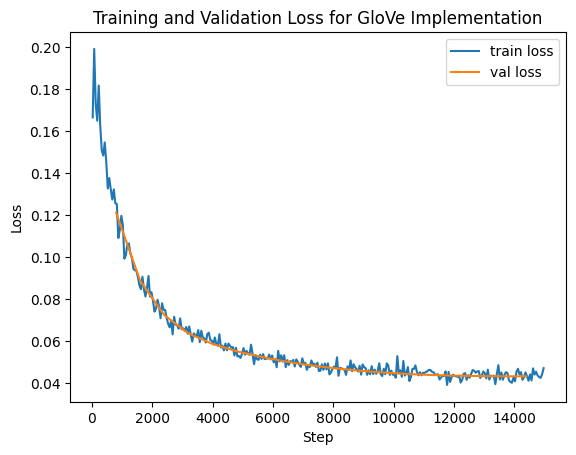

total full passes over corpus: 0


In [26]:
#GloVe plotting
chunk_size = 50   #num batches that training loss is averaged over (to smooth curve)

plt.title("Training and Validation Loss for GloVe Implementation")
plot_results(glove_train_losses, glove_val_losses, glove_num_completed_epochs, chunk_size)

# Model Evaluation on Sentiment Analysis

In [27]:
#model evaluation
#brief training on lstm sentiment analysis

#hyperparameter structure: [Baseline, Skipgram, Cbow, SGNS, GloVe]  (baseline is random embs)
#many will likely just share the same value across all models even when optimized

total_steps = 700
warmup_steps = 1
batch_size = 256
num_workers = 2
lr=[3e-3, 3e-3, 3e-3, 3e-3, 3e-3]
weight_decay = [0.01, 0.01, 0.01, 0.01, 0.01]
start_factor = 1e-5
clip_norm = [1.0, 1.0, 1.0, 1.0, 1.0]

#new hyperparams
h_model = 512   #lstm hidden dim (often >= emb dim)
dropout = [0.1, 0.1, 0.1, 0.1, 0.1]   #lstm dropout
num_layers = 2  #depth of lstm; should be not too big
use_ln = [True, True, True, True, True]   #uses layer norm before embeddings are fed to lstm
use_affine = [True, True, True, True, True] #controls whether ln is just rescaling or also has its own parameters (does nothing if use_ln is False)
freeze_embs = [True, True, True, True, True]  #freeze final model embeddings; note False will create a copy so original embs can still be used without retraining if later changed to True
combine_embs = [True, True, True, True, True]  #combines center and context embeddings to get final embeddings for lstm
return_accs = True  #evals val accs when evaluating on val set

eval_every = 50
num_val_batches = 0  #formula: eval_every : num_val_batches / 9 gives train to val compute ratio (formula comes from 90-10 split)


models = [None, sg_model, cbow_model, sgns_model, glove_model]  #None: place holder for baseline
baseline_model = Skipgram(models[1].d_model, V) #any untrained model from init will work
models[0] = baseline_model

lstm_models = [0 for _ in range(len(models))]
model_names = ["Baseline (Random Embeddings)", "Pure SkipGram", "Pure CBoW", "SGNS", "GloVe"]   #for plot titles
sentiment_train_losses = [[] for _ in range(len(models))]
sentiment_val_losses = [[] for _ in range(len(models))]
sentiment_val_accs = [[] for _ in range(len(models))]
sentiment_num_completed_epochs = [0 for _ in range(len(models))]

set_seed(0)
sst2_train_ds = SST2Dataset(sst2_train_ids, sst2_train_lengths, sst2_train_labels)
sst2_val_ds = SST2Dataset(sst2_val_ids, sst2_val_lengths, sst2_val_labels)
sst2_train_loader = DataLoader(sst2_train_ds, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=num_workers, drop_last=True, collate_fn=collate_sort)
sst2_val_loader = DataLoader(sst2_val_ds, batch_size=batch_size, pin_memory=True, num_workers=num_workers, collate_fn=collate_sort)

for i, model in enumerate(models):
    set_seed(0)
    if combine_embs[i]:
      embs = model.emb_center.weight.detach().clone() + model.emb_context.weight.detach().clone()
    else:
      #for cbow default to using context embs; else default to using center embs (ensures the input embeddings are used for eval)
      if i == 2:
        embs = model.emb_context.weight.detach().clone()
      else:
        embs = model.emb_center.weight.detach().clone()


    lstm_model = Sentiment_Analaysis(embs, h_model, num_classes=2, dropout=dropout[i], num_layers=num_layers, freeze_embs=freeze_embs[i], use_ln=use_ln[i], use_affine=use_affine[i]).to(device)
    lstm_models[i] = lstm_model

    optim = torch.optim.AdamW(lstm_model.parameters(), lr=lr[i], weight_decay=weight_decay[i])

    warmup = torch.optim.lr_scheduler.LinearLR(
        optim,
        start_factor=start_factor,
        end_factor=1.0,
        total_iters=warmup_steps
    )
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optim,
        T_max=total_steps - warmup_steps
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optim,
        schedulers=[warmup, cosine],
        milestones=[warmup_steps]
    )

    print(model_names[i], ":", sep="")
    final_train_args = (lstm_model, total_steps, sst2_train_loader, sst2_val_loader, eval_every, optim, scheduler, clip_norm[i], num_val_batches, False, return_accs, True)
    if return_accs:
      sentiment_train_losses[i], sentiment_val_losses[i], sentiment_val_accs[i], sentiment_num_completed_epochs[i] = train(*final_train_args)
    else:
      sentiment_train_losses[i], sentiment_val_losses[i], sentiment_num_completed_epochs[i] = train(*final_train_args)

Baseline (Random Embeddings):
step: 50 train loss (noisy): 0.5866663455963135, val loss: 0.5978522896766663, val acc: 0.6880733944954128
step: 100 train loss (noisy): 0.5001673102378845, val loss: 0.5738497078418732, val acc: 0.7213302752293578
step: 150 train loss (noisy): 0.4646478295326233, val loss: 0.5165385752916336, val acc: 0.7545871559633027
step: 200 train loss (noisy): 0.28907859325408936, val loss: 0.5395547300577164, val acc: 0.7924311926605505
step: 250 train loss (noisy): 0.27293986082077026, val loss: 0.42498625814914703, val acc: 0.8142201834862385
step: 300 train loss (noisy): 0.21639440953731537, val loss: 0.4299715682864189, val acc: 0.8291284403669725
step: 350 train loss (noisy): 0.19994038343429565, val loss: 0.48749788105487823, val acc: 0.8096330275229358
step: 400 train loss (noisy): 0.19105032086372375, val loss: 0.4566007927060127, val acc: 0.8325688073394495
step: 450 train loss (noisy): 0.16076067090034485, val loss: 0.442464679479599, val acc: 0.840596330

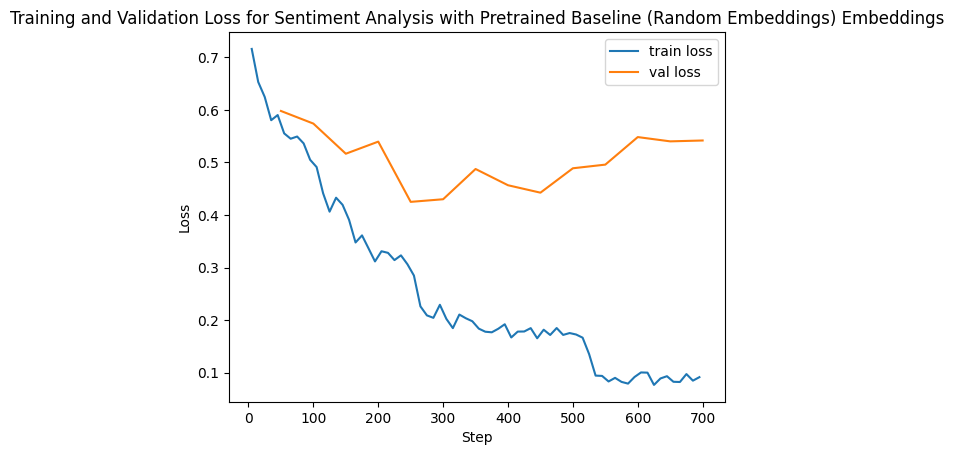

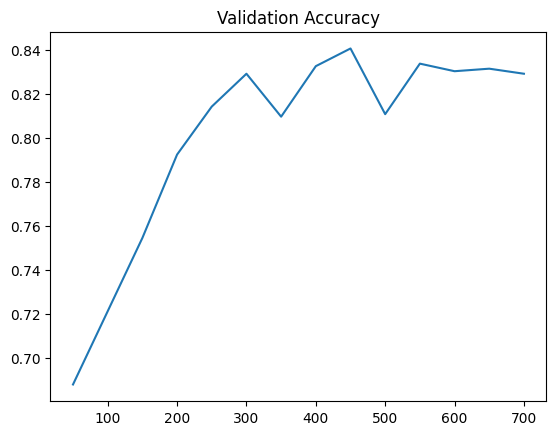

total full passes over corpus: 2


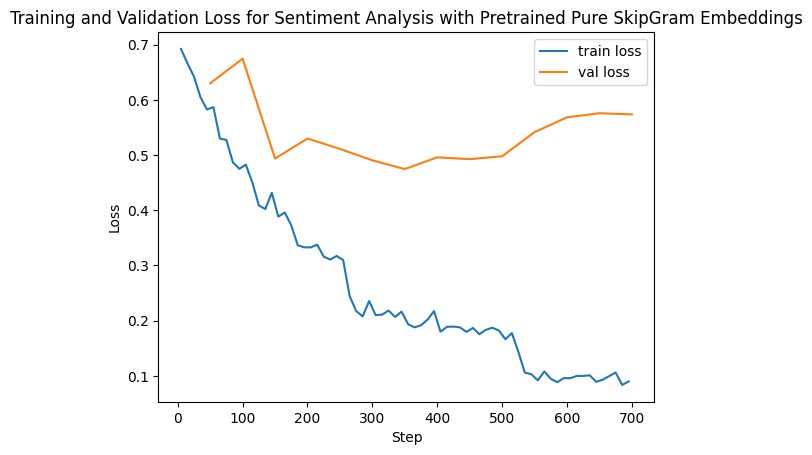

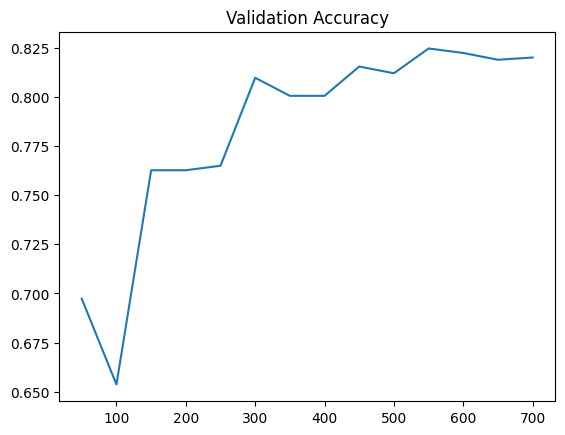

total full passes over corpus: 2


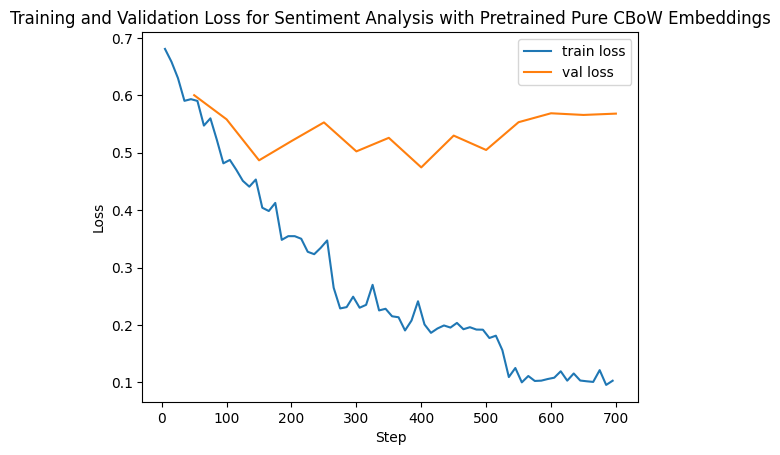

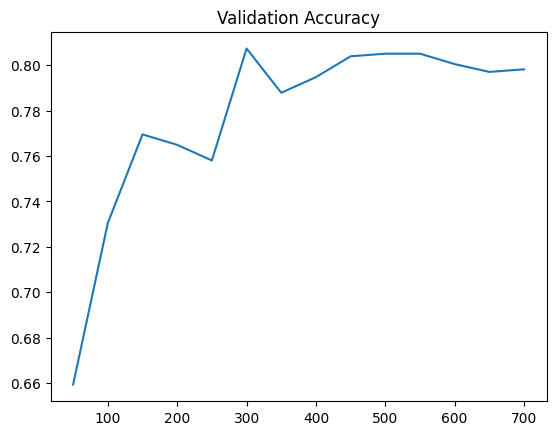

total full passes over corpus: 2


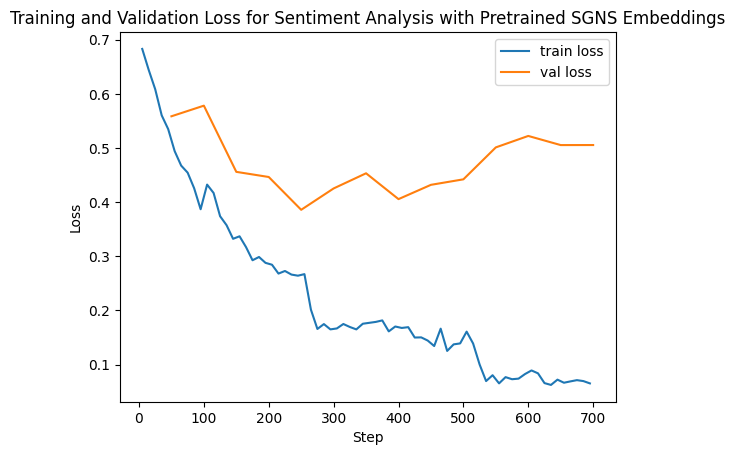

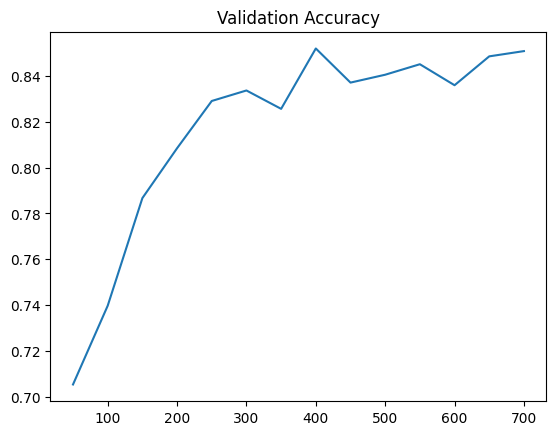

total full passes over corpus: 2


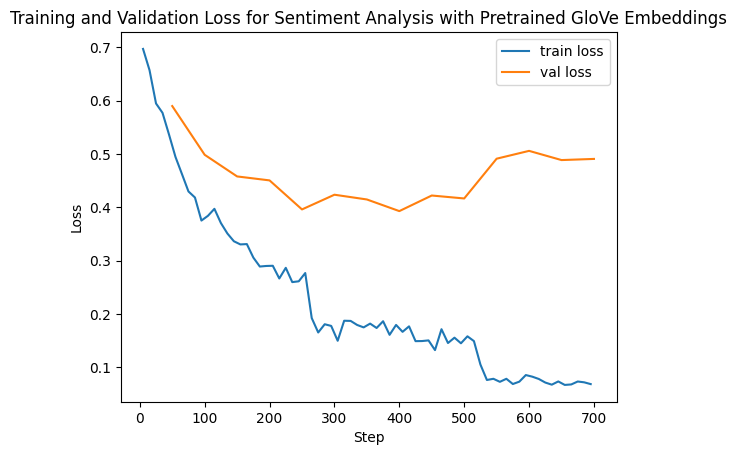

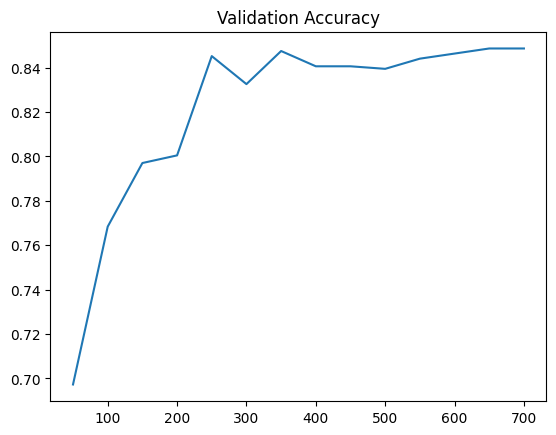

total full passes over corpus: 2


In [28]:
#eval plotting

chunk_size = 10   #num batches that training loss is averaged over (to smooth curve)

for i in range(len(models)):
  plt.title(f"Training and Validation Loss for Sentiment Analysis with Pretrained {model_names[i]} Embeddings")
  if return_accs:
    plot_results(sentiment_train_losses[i], sentiment_val_losses[i], sentiment_num_completed_epochs[i], chunk_size, sentiment_val_accs[i])
  else:
    plot_results(sentiment_train_losses[i], sentiment_val_losses[i], sentiment_num_completed_epochs[i], chunk_size)

In [29]:
#final test set eval

sst2_test_ds = SST2Dataset(sst2_test_ids, sst2_test_lengths, sst2_test_labels)
test_loader = DataLoader(sst2_test_ds, batch_size=batch_size, pin_memory=True, num_workers=num_workers, collate_fn=collate_sort)

for i, lstm_model in enumerate(lstm_models):
    print(model_names[i], " final sentiment analysis test accuracy:", sep="")
    test_loss, test_acc = eval(lstm_model, test_loader, num_batches=0, return_accs=True, pack=True)
    print(test_acc)


Baseline (Random Embeddings) final sentiment analysis test accuracy:
0.8291284403669725
Pure SkipGram final sentiment analysis test accuracy:
0.819954128440367
Pure CBoW final sentiment analysis test accuracy:
0.7981651376146789
SGNS final sentiment analysis test accuracy:
0.8509174311926605
GloVe final sentiment analysis test accuracy:
0.8486238532110092


## Brief Intrinsic Evaluation

In [30]:
@torch.no_grad()
def word_analogies(embs):
  #prints word analogy results for given embeddings
  w1, w2, w3, w4 = "king", "man", "woman", "queen"
  t1, t2, t3, t4 = (torch.tensor(sp.encode(w, out_type=int)) for w in (w1, w2, w3, w4))
  e1, e2, e3, e4 = (embs[t].mean(dim=0) for t in (t1, t2, t3, t4))
  query = e1 - e2 + e3
  sims = torch.cosine_similarity(query, embs, dim=1)
  top_k = torch.topk(sims, k=20)
  words = [sp.decode( [idx.item()] ) for idx in top_k[1]]
  print(words)
  print(torch.cosine_similarity(query, e4, dim=0))

for i in range(len(models)):
  print(model_names[i], " word analogies:", sep="")
  word_analogies(models[i].emb_center.weight.detach().clone())

Baseline (Random Embeddings) word analogies:
['king', 'woman', 'gymnast', 'boy', 'bow', 'Image', '取', '灿', 'Scrubs', 'Zu', 'refract', 'Ramos', 'vegetation', 'rra', 'vitational', 'Mini', 'fraction', 'Solar', 'Amy', 'మ']
tensor(-0.0359)
Pure SkipGram word analogies:
['king', 'woman', 'plan', '/', 'Bry', 'Michel', '●', 'Archive', 'readers', 'iff', 'ῆ', 'Lip', 'Herald', 'Block', 'limestone', 'պ', 'Immigration', '000', 'clause', 'entrance']
tensor(-0.0581, device='cuda:0')
Pure CBoW word analogies:
['king', 'woman', 'plan', 'Salvador', 'franc', 'vampire', 'Sher', 'blame', 'naming', 'Herald', 'explore', 'Lumpur', 'Finance', 'edge', 'furniture', 'adjust', 'coil', 'none', 'biological', 'Witness']
tensor(0.5770, device='cuda:0')
SGNS word analogies:
['woman', 'king', 'Green', 'publisher', 'visitors', 'Jiang', 'federal', 'cheese', '×', 'banks', 'Lutheran', 'St', 'judge', 'publish', 'Blo', 'Co', 'making', 'Em', 'leak', 'Gill']
tensor(0.0586, device='cuda:0')
GloVe word analogies:
['woman', 'king'